# 5a. Setup environment

## Load packages

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
from sklearn.decomposition import PCA
from openTSNE import TSNE
import umap
from scipy.cluster import hierarchy
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc
from scipy.stats import gaussian_kde

## Define file paths

### Set input directory

In [2]:
# main dir
wd = "/project/shefflab/processed/gomez_atac/results_pipeline/differential/geniml_univ_cc"

# path of the scATAC figment files
scATAC_dir = os.path.join(wd, "scATAC")
# path of the pseudo-bulk data 
pseudobulk_dir = os.path.join(wd, "pseudobulk_data")
# path of the pseudo-bulk data by predefined cell type clusters
cluster_dir = os.path.join(pseudobulk_dir,"cell_type_cluster")
# cluster barcodes table
cluster_barcode = os.path.join(scATAC_dir,"cluster_barcode_2024-01-29.csv")

# path for reninness score results
reninScore_dir = "/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/reninness_score_output_new/universe_cc"

# Sweep configs (dim × margin) — each is a sub-dir of reninScore_dir
configs = [
    "d50_e10_m0.1",
    "d50_e10_m1.0",
    "d10_e10_m0.1",
    "uc_d10_e10_m1.0",
    "d5_e10_m0.1",
    "d5_e10_m1.0",    
    "d3_e10_m0.1",
    "d3_e10_m1.0",
]

# Result-tag sub-folders (set by the `result_tag` arg of the score script)
bulk_res = ""
loo_res = "loocv"
pseudobulk_res = "pseudobulk"
sc_res = "sc"

# Per-config helpers (filenames now embed the config tag instead of `_mm10`)
def cfg_root(cfg):
    """Directory holding the trained model (model_<cfg>.tsv)."""
    return os.path.join(reninScore_dir, cfg)

def cfg_res_dir(cfg, tag):
    """Directory holding scored outputs for one cfg × data-source tag."""
    return os.path.join(reninScore_dir, cfg, tag)

def doc_embed(cfg):
    if result_tag == bulk_res:
        return "test_starspace_embed.txt"
    else:
        return f"{cfg}_starspace_embed.txt"

def word_embed(cfg):
    return f"model_{cfg}.tsv"

# Score CSVs (fixed names within each result-tag dir; no _mm10 suffix in new pipeline)
score_filename = "reninness_score.csv"
similarity_filename = "similarity_score_rl.csv"



In [3]:
# Build model dict of paths per config 
model_paths = {
    cfg: os.path.join(cfg_res_dir(cfg, bulk_res))
    for cfg in configs
}

# Build output dict of paths per config (bulk_res,loo_res,pseudobulk_res,sc_res)
result_tag = loo_res
output_paths = {
    cfg: os.path.join(cfg_res_dir(cfg, result_tag))
    for cfg in configs
}

score_paths = {cfg: os.path.join(output_paths[cfg], score_filename) for cfg in configs}

### Set output directory

In [4]:
# path to save the bed files for the pseudo-bulk data by cell barcode
barcode_dir = os.path.join(pseudobulk_dir,"cell_barcodes")

# Per-config plot dirs (one set per cfg, rooted at that cfg's output dir)
plot_dirs = {
    cfg: os.path.join(output_paths[cfg], "plot", "reninness_score")
    for cfg in configs
}
bar_plts = {cfg: os.path.join(plot_dirs[cfg], "bar") for cfg in configs}
tsne_plts = {cfg: os.path.join(plot_dirs[cfg], "tsne") for cfg in configs}
heatmap_plts = {cfg: os.path.join(plot_dirs[cfg], "heatmap") for cfg in configs}

# Shared acc dir (cross-config comparison plots live above the per-cfg trees)
acc_plt = os.path.join(reninScore_dir, "plot", "reninness_score", "acc")

## Region Embedding UMAP Color by DeSeq2 log2FoldChange

regions get colored by log2FoldChange from a DESeq2 result CSV, with a diverging colormap centered at 0 (royalblue → lightgrey → darkorange). Labels stay as triangles.

Optionally also overlays projected samples on top (colored by reninness score on a second colorbar) so you can see how the per-sample embeddings sit relative to the FC-coloured region cloud.

In [5]:
# get the embeddings from raw starspace outputs

def get_embedding_matrix(path_embeded_document, path_word_embedding, no_labels):
    X, y = get_sample_embedding(path_embeded_document)
    X_label, y_label = get_label_embedding(path_word_embedding, no_labels)

    X.extend(X_label)
    y.extend(y_label)

    return X, y


def get_sample_embedding(path_embeded_document):
    document_embedding = pd.read_csv(path_embeded_document, header=None, skiprows=4)
    has_labels_in_doc = document_embedding[0].astype(str).str.contains("__label__").any()

    if has_labels_in_doc:
        # legacy format
        document_embedding = (document_embedding[0].str.split('__label__', expand=True))
        document_embedding[1] = document_embedding[1].shift(1)
        document_embedding = document_embedding.dropna()

        X = document_embedding[0].str.split(' ', expand=True)
        X = X[list(X)[0:-1]].astype(float)
        X = list(X.values)
        y = list(document_embedding[1])
        return X, y

    # current format: every other row (1, 3, 5, ...) holds an embedding vector
    embed_lines = document_embedding[0].iloc[1::2].astype(str).str.strip()
    X = [np.array([float(v) for v in line.split()]) for line in embed_lines]
    y = ["sample"] * len(X)
    return X, y


def get_label_embedding(path_word_embedding, no_labels):

    labels = []
    label_embedding = []
    word_embedding = pd.read_csv(path_word_embedding, sep = '\t', header = None)
    embedding = word_embedding.tail(no_labels).reset_index()
    
    for l in range(no_labels):
        label_embedding.append((np.array(embedding.iloc[l])[2:]))
        labels.append(list(embedding.iloc[l])[1].replace('__label__',''))

    return label_embedding, labels

def reduce_embed_dim(input_data, labels, input_score, model_type = 'umap', n_neighbours = 100, metric = 'euclidean', model = None):
    np.random.seed(42)
    if model is None:
        if(model_type == 'umap'):
            plot_model = umap.UMAP(metric=metric, min_dist=0.01, n_components=2, n_neighbors = n_neighbours, random_state = 42)
            data = pd.DataFrame(plot_model.fit_transform(input_data)) 
        if(model_type == 'tsne'):
            plot_model = TSNE(n_components = 2, 
                              metric=metric, 
                              perplexity=n_neighbours,
                              random_state=42, 
                              verbose=True)
            plot_model = plot_model.fit(input_data.astype(float))
            data =  pd.DataFrame(plot_model)
        if(model_type == 'pca'):
            plot_model = PCA(n_components = 2)
            data = pd.DataFrame(plot_model.fit_transform(input_data)) 
    else:
        plot_model = model
        data = pd.DataFrame(plot_model.transform(input_data.astype(float))) 

    data = pd.DataFrame({'1':data[0],
                         '2':data[1],
                         "label":[str(y1) for y1 in labels]})

    data = pd.concat([data, input_score], axis=1)
    data['marker'] = 'o'
    
    if model is None:
        data.loc[data['label'] == 'Non_Renin', 'marker'] = 's'
        
    data.iloc[-2:, data.columns.get_loc('marker')] = '^'
    
    
    return plot_model, data

def fit_region_embedding(
    path_word_embedding,
    method="tsne",
    perplexity=30,        # tsne only
    n_neighbors=15,       # umap only
    min_dist=0.1,         # umap only
    random_state=42,
    max_regions=5000,
    metric="cosine",
):
    """Fit a 2D embedding on (sub-sampled regions + labels).

    `method="tsne"` uses openTSNE (already imported as `TSNE`); `method="umap"`
    uses umap-learn (already imported as `umap`). In either case the returned
    `embedding` object has a usable `.transform(...)` method, so sample
    embeddings can be projected onto this background later.

    Returns a dict with `method`, `embedding`, `region_coords`, `label_coords`,
    `region_names`, `label_names`.
    """
    region_emb, region_names, label_emb, label_names = load_region_label_embeddings(
        path_word_embedding
    )

    rng = np.random.default_rng(random_state)
    if len(region_emb) > max_regions:
        idx = rng.choice(len(region_emb), max_regions, replace=False)
        region_emb_plot = region_emb[idx]
        region_names_plot = [region_names[i] for i in idx]
    else:
        region_emb_plot = region_emb
        region_names_plot = region_names

    background = np.vstack([region_emb_plot, label_emb]).astype(float)
    n_reg = len(region_emb_plot)

    if method == "tsne":
        p_eff = min(perplexity, len(background) - 1)
        print(f"  t-SNE on {len(background)} pts "
              f"(perplexity={p_eff}, metric={metric}) ...")
        tsne = TSNE(
            n_components=2,
            perplexity=p_eff,
            random_state=random_state,
            metric=metric,
            verbose=True,
        )
        embedding = tsne.fit(background)
        coords = np.asarray(embedding)
    elif method == "umap":
        nn_eff = min(n_neighbors, len(background) - 1)
        print(f"  UMAP on {len(background)} pts "
              f"(n_neighbors={nn_eff}, min_dist={min_dist}, metric={metric}) ...")
        embedding = umap.UMAP(
            n_components=2,
            n_neighbors=nn_eff,
            min_dist=min_dist,
            metric=metric,
            random_state=random_state,
        )
        coords = embedding.fit_transform(background)
    else:
        raise ValueError(f"method must be 'tsne' or 'umap', got {method!r}")

    return {
        "method": method,
        "embedding": embedding,
        "region_coords": coords[:n_reg],
        "label_coords": coords[n_reg:],
        "region_names": region_names_plot,
        "label_names": label_names,
    }

def load_region_label_embeddings(path_word_embedding, label_prefix="__label__"):
    """Read `model_<combo>.tsv` and split into (region, label) embeddings.

    Mirrors geniml.bedspace.visualization.load_label_embeddings (skiprows=1,
    rows starting with `__label__` are labels, everything else are regions).
    Returns: region_emb, region_names, label_emb, label_names.
    """
    df = pd.read_csv(path_word_embedding, sep="\t", header=None, skiprows=1)
    is_label = df[0].astype(str).str.contains(label_prefix, na=False)

    region_df = df[~is_label]
    label_df = df[is_label].copy()
    label_df[0] = label_df[0].str.replace(label_prefix, "", regex=False)

    region_names = list(region_df[0])
    region_emb = region_df.iloc[:, 1:].values.astype(float)
    label_names = list(label_df[0])
    label_emb = label_df.iloc[:, 1:].values.astype(float)
    return region_emb, region_names, label_emb, label_names

In [6]:
from scipy.stats import gaussian_kde

# Diverging colormap with an alpha gradient: ends opaque, centre nearly
# transparent. Scatter receives RGBA per point from the cmap (alpha
# interpolates with the FC value), so FC≈0 regions fade and the strongly
# up/down regions pop. Adjust the second tuple's alpha (0.05) to taste —
# higher = more visible centre, lower = more transparent.
FOLDCHANGE_CMAP = colors.LinearSegmentedColormap.from_list(
    "fc_royalblue_grey_darkorange",
    [
        colors.to_rgba("royalblue", 1.0),
        colors.to_rgba("lightgrey", 0.05),
        colors.to_rgba("darkorange", 1.0),
    ],
)


def _plot_value_distribution(ax, values, norm, bins=40):
    """Horizontal histogram + KDE of `values` aligned to a colorbar's y-range.

    Adapted from `geniml.bedspace.tests.test_training_evaluation._plot_value_distribution`.
    Values are passed through `norm` so the y-axis lives in the colorbar's
    normalized color space [0, 1] — the only axis on which matplotlib
    colorbars are guaranteed to be linear (under `TwoSlopeNorm` data-space is
    nonlinear, so plotting density in data-space would misalign the zero ref).

    The histogram x-axis is **count** (number of values per bin); the KDE
    overlay is rescaled by `N * bin_width` so it sits on the same count
    scale as the bars (count_in_bin ≈ density × N × bin_width).
    """
    raw = np.asarray(values, dtype=float)
    raw = raw[np.isfinite(raw)]  # drop NaN / +-inf from upstream foldchange_map
    normed = np.asarray(norm(raw))
    # Clip to the colorbar's [0, 1] normalized space so points beyond the
    # data bound (i.e. the clipped extremes in the scatter) are still
    # represented at the edges of the histogram instead of silently dropped.
    normed = np.clip(normed, 0.0, 1.0)
    n = len(normed)
    bin_width = 1.0 / bins

    counts, _, patches = ax.hist(
        normed, bins=bins, range=(0.0, 1.0),
        orientation="horizontal", color="gray",
        alpha=0.4, density=False, edgecolor="black", linewidth=0.3,
    )
    # rasterize histogram bar fills (kept vector by default would be fine for
    # 40 bars, but keeps the SVG visually consistent with other rasterized
    # data-bar fills in the notebook)
    for p in patches:
        p.set_rasterized(True)
    if n > 1 and float(np.std(normed)) > 0:
        try:
            kde = gaussian_kde(normed)
            yy = np.linspace(0.0, 1.0, 200)
            # gaussian_kde returns density; rescale to the same count scale as
            # the histogram so the curve overlays the bars.
            ax.plot(kde(yy) * n * bin_width, yy, color="black", linewidth=1.5)
        except Exception:
            pass
    zero_norm = float(norm(0.0))
    if 0.0 <= zero_norm <= 1.0:
        ax.axhline(
            zero_norm, color="dimgray", linewidth=0.6, linestyle="--", alpha=0.7
        )
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([])
    ax.set_xlabel("Count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    for side in ("left", "right", "top"):
        ax.spines[side].set_visible(False)


def load_foldchange_map(
    deseq_csv,
    name_column=None,
    fc_column="log2FoldChange",
    coord_columns=("seqnames", "start", "end"),
    coord_separator="_",
    start_offset=0,
):
    """Load a `{region_name: log2FoldChange}` dict from a DESeq2 result CSV.

    Two key-construction modes:

    1. **Single-column** (`name_column` set, OR `coord_columns` set to None) —
       use the named column verbatim as the key.
    2. **Multi-column coords** (default) — build keys as
       `f"{seqnames}{sep}{start+start_offset}{sep}{end}"` from three columns,
       which matches the `chr1_3094411_3095613` style used in
       `model_<combo>.tsv`. Use `start_offset=-1` if your model TSV uses
       0-based BED coordinates while the DESeq CSV is 1-based.

    Returns
    -------
    dict[str, float]
    """
    df = pd.read_csv(deseq_csv)

    if name_column is not None:
        keys = df[name_column].astype(str)
    elif coord_columns is not None and all(c in df.columns for c in coord_columns):
        c_seq, c_start, c_end = coord_columns
        keys = (
            df[c_seq].astype(str)
            + coord_separator
            + (df[c_start].astype(int) + start_offset).astype(str)
            + coord_separator
            + df[c_end].astype(int).astype(str)
        )
    else:
        keys = df[df.columns[0]].astype(str)

    print(f"  load_foldchange_map: {len(df)} rows from {deseq_csv}")
    print(f"  example keys: {list(keys[:3])}")
    return dict(zip(keys, df[fc_column].astype(float)))


def plot_foldchange_on_region_embedding(
    input_dir,
    foldchange_map,
    tag=None,
    method="umap",
    word_embed_dir=None,
    word_embed_combo=None,
    perplexity=30,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
    max_regions=5000,
    metric="cosine",
    tsne_state=None,
    figsize=(16, 10),
    dpi=800,
    output_dir=None,
    region_size=10,
    label_size=200,
    annotate_labels=True,
    project_samples=False,
    score_filename=None,
    sample_size=30,
    sample_alpha=0.85,
    fc_limit=None,
    fc_percentile=95,
):
    """Fit (or reuse) a region+label embedding, color regions by log2FC, and
    optionally overlay projected sample points on top.

    Layout follows the reference `create_umap_foldchange` /
    `create_tsne_foldchange` in
    `geniml.bedspace.tests.test_training_evaluation`: a GridSpec of
    [scatter, colorbar, density] where the right-side density axis shows a
    horizontal histogram + KDE of the FC values aligned to the colorbar's
    normalized [0, 1] y-range. The density panel's x-axis is **count**
    (samples per bin). When `project_samples=True`, an extra colorbar column
    for the reninness-score scale is inserted.

    The FC color range is **symmetric around 0** by default — vmax is
    `max(|min FC|, |max FC|)`, vmin is `-vmax`. Pass `fc_limit=N` to fix the
    range to ±N (e.g. for comparable plots across contrasts).

    Saves as SVG with the data-point layers (region scatter, sample scatter,
    histogram bars) rasterized at `dpi`; axes / text / colorbars / triangles
    stay vector.

    Saves: `<output_dir>/<tag>_region_foldchange_<method>.svg`
    """
    if tag is None:
        tag = os.path.basename(input_dir.rstrip("/"))
    if word_embed_dir is None:
        word_embed_dir = input_dir
    if word_embed_combo is None:
        word_embed_combo = os.path.basename(word_embed_dir.rstrip("/"))
    if output_dir is None:
        output_dir = tsne_plt
    os.makedirs(output_dir, exist_ok=True)

    word_path = os.path.join(word_embed_dir, word_embed(word_embed_combo))

    print(f"\n=== {tag} : region+label {method.upper()} colored by log2FC ===")
    print(f"  word: {word_path}")

    if tsne_state is None:
        tsne_state = fit_region_embedding(
            word_path,
            method=method,
            perplexity=perplexity,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state,
            max_regions=max_regions,
            metric=metric,
        )
    else:
        method = tsne_state["method"]
        print(f"  reusing pre-fit {method.upper()}")

    region_coords = tsne_state["region_coords"]
    label_coords = tsne_state["label_coords"]
    region_names = tsne_state["region_names"]
    label_names = tsne_state["label_names"]

    fc_values = np.array([foldchange_map.get(n, 0.0) for n in region_names])
    n_hit = int(np.sum([n in foldchange_map for n in region_names]))
    print(f"  matched FC for {n_hit}/{len(region_names)} regions "
          f"(missing default to 0.0)")
    if n_hit == 0:
        print(f"  ! example region names from model TSV: {region_names[:3]}")
        ex_keys = list(foldchange_map.keys())[:3]
        print(f"  ! example keys in foldchange_map:      {ex_keys}")
        print(f"  ! → check coord_columns / start_offset in load_foldchange_map")

    # FC norm — symmetric around 0. Default vmax is the `fc_percentile`-th
    # percentile of |fc| (default 95), so a handful of extreme outliers
    # don't compress the bulk of the distribution into near-grey. Regions
    # beyond the bound clip to the colormap extreme — standard genomics
    # heatmap / volcano-plot convention. Pass `fc_limit=N` to fix the
    # bound exactly (and bypass percentile clipping).
    abs_fc = np.abs(np.asarray(fc_values, dtype=float))
    nonzero_abs = abs_fc[abs_fc > 0]
    if fc_limit is not None:
        fc_abs = float(fc_limit)
        bound_source = f"fc_limit={fc_abs:g}"
    elif nonzero_abs.size:
        fc_abs = float(np.nanpercentile(nonzero_abs, fc_percentile))
        fc_max = float(nonzero_abs.max())
        n_clipped = int((abs_fc > fc_abs).sum())
        bound_source = (
            f"P{fc_percentile} of |fc| (max={fc_max:g}; "
            f"{n_clipped} region(s) clipped at ±{fc_abs:g})"
        )
    else:
        fc_abs = 0.0
        bound_source = "all fc = 0 (degenerate)"
    if fc_abs > 0:
        fc_norm = colors.TwoSlopeNorm(vmin=-fc_abs, vcenter=0, vmax=fc_abs)
    else:
        # degenerate: all FC = 0 (e.g. universe mismatch). Pick a small range
        # so the cmap doesn't blow up; the plot will still be uninformative.
        fc_norm = colors.Normalize(vmin=-1.0, vmax=1.0)
    print(f"  fc range used: ±{fc_abs:g}  [{bound_source}]")

    # GridSpec layout: scatter | fc-colorbar | (optional) score-colorbar | density
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    if project_samples:
        gs = fig.add_gridspec(1, 4, width_ratios=[20, 0.5, 0.5, 3], wspace=0.05)
        ax = fig.add_subplot(gs[0, 0])
        cax_fc = fig.add_subplot(gs[0, 1])
        cax_score = fig.add_subplot(gs[0, 2])
        dax = fig.add_subplot(gs[0, 3])
    else:
        gs = fig.add_gridspec(1, 3, width_ratios=[20, 0.5, 3], wspace=0.05)
        ax = fig.add_subplot(gs[0, 0])
        cax_fc = fig.add_subplot(gs[0, 1])
        cax_score = None
        dax = fig.add_subplot(gs[0, 2])

    # alpha=None lets the cmap's per-point RGBA alpha pass through; linewidths=0
    # avoids the rim artefact from translucent fills with a same-color stroke.
    # rasterized=True keeps the SVG small for thousands of region dots.
    sc_fc = ax.scatter(
        region_coords[:, 0], region_coords[:, 1],
        c=fc_values, cmap=FOLDCHANGE_CMAP, norm=fc_norm,
        s=region_size, alpha=None, marker="o", linewidths=0,
        label=f"Regions (n={len(region_coords)})",
        #rasterized=True,
    )
    fig.colorbar(sc_fc, cax=cax_fc, label="log2FoldChange")
    # Force the scatter panel itself to be visually square. set_box_aspect
    # fixes height:width = 1:1 regardless of the data x:y range (which can
    # be lopsided for UMAP/t-SNE), unlike set_aspect('equal') which makes
    # *data units* equal and would leave the box wider-than-tall when the
    # embedding spreads more on one axis.
    ax.set_box_aspect(1)
    _plot_value_distribution(dax, fc_values, fc_norm)

    sample_coords = None
    scores_df = None
    if project_samples:
        if score_filename is None:
            score_filename = score_filename_default
        doc_path = os.path.join(input_dir, doc_embed(tag))
        score_path = (
            score_filename if os.path.isabs(score_filename)
            else os.path.join(input_dir, score_filename)
        )
        print(f"  doc:   {doc_path}")
        print(f"  score: {score_path}")

        sample_X, _ = get_sample_embedding(doc_path)
        sample_X = np.asarray(sample_X, dtype=float)
        sample_coords = _transform_samples(tsne_state, sample_X)

        scores_df = pd.read_csv(score_path)
        if "filename" in scores_df.columns and "name" not in scores_df.columns:
            scores_df = scores_df.rename(columns={"filename": "name"})
        score_arr = scores_df["score"].astype(float).to_numpy()
        if len(score_arr) > len(sample_X):
            score_arr = score_arr[:len(sample_X)]
        elif len(score_arr) < len(sample_X):
            score_arr = np.concatenate(
                [score_arr, np.zeros(len(sample_X) - len(score_arr))]
            )
        score_abs = max(abs(score_arr.min()), abs(score_arr.max()), 1e-6)
        score_norm = colors.TwoSlopeNorm(vmin=-score_abs, vcenter=0, vmax=score_abs)
        score_cmap = colors.LinearSegmentedColormap.from_list(
            "blue_grey_orange", ["royalblue", "lightgrey", "darkorange"]
        )
        sc_score = ax.scatter(
            sample_coords[:, 0], sample_coords[:, 1],
            c=score_arr, cmap=score_cmap, norm=score_norm,
            s=sample_size, alpha=sample_alpha, marker="o",
            edgecolors="black", linewidths=0.4,
            label=f"Samples (n={len(sample_coords)})",
            #rasterized=True,
        )
        fig.colorbar(sc_score, cax=cax_score, label="reninness score")

    label_colors = [
        "darkorange" if n.lower() == "renin"
        else "royalblue" if "non" in n.lower() and "renin" in n.lower()
        else "black"
        for n in label_names
    ]
    # Label triangles stay vector — only 2 of them, want crisp edges.
    for i, (name, col) in enumerate(zip(label_names, label_colors)):
        ax.scatter(
            label_coords[i, 0], label_coords[i, 1],
            c=[col], s=label_size, marker="^",
            edgecolors="black", linewidths=1.5,
            label=name, zorder=10,
        )
        if annotate_labels:
            ax.annotate(
                name, (label_coords[i, 0], label_coords[i, 1]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=10, fontweight="bold",
            )

    axis_label = "t-SNE" if method == "tsne" else "UMAP"
    ax.set_xlabel(f"{axis_label} 1", fontsize=12)
    ax.set_ylabel(f"{axis_label} 2", fontsize=12)
    title_extra = " + sample projection" if project_samples else ""
    ax.set_title(f"{tag}: regions colored by log2FoldChange{title_extra}",
                 fontsize=13)
    ax.legend(loc="best", fontsize=9)

    out_path = os.path.join(
        output_dir, f"{tag}_region_foldchange_{method}.svg"
    )
    plt.savefig(out_path, format="svg", dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"  saved {out_path}")

    return {
        "tag": tag,
        "method": method,
        "embedding": tsne_state["embedding"],
        "region_coords": region_coords,
        "label_coords": label_coords,
        "label_names": label_names,
        "region_names": region_names,
        "foldchange_values": fc_values,
        "sample_coords": sample_coords,
        "scores": scores_df,
    }


In [ ]:
fc_map = load_foldchange_map("/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/differential/geniml_univ_cc/deseq/combined_deseq_log2fc.csv")

for cfg in configs:
    os.makedirs(tsne_plts[cfg], exist_ok=True)
    plot_foldchange_on_region_embedding(
        model_paths[cfg],
        foldchange_map=fc_map,
        method="umap",
        region_size=20,
        max_regions=5000,
        fc_limit=2,
        output_dir=tsne_plts[cfg],
    )


## Accuracy & AUC

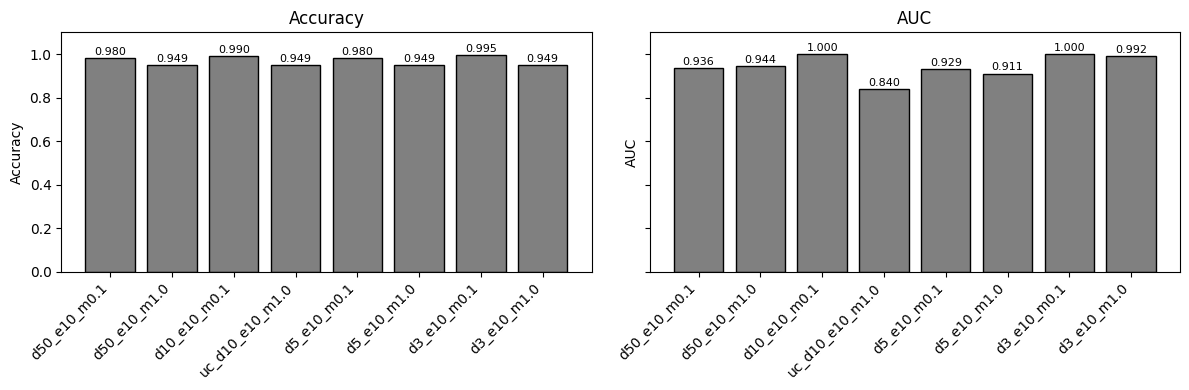

In [8]:
# Compute accuracy & AUC per config from reninness_score.csv.
# Accuracy rule: correct if (file_label == 'Renin' and score > 0) or
# (file_label != 'Renin' and score < 0).
acc_dict, auc_dict = {}, {}
for cfg, path in score_paths.items():
    df = pd.read_csv(path)
    is_renin = df["file_label"] == "Renin"
    correct = (is_renin & (df["score"] > 0)) | (~is_renin & (df["score"] < 0))
    acc_dict[cfg] = correct.mean()
    fpr, tpr, _ = roc_curve(is_renin.astype(int), df["score"])
    auc_dict[cfg] = auc(fpr, tpr)

# Two-panel bar plot: Accuracy (left), AUC (right). Gray bars, value labels on top.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x = np.arange(len(configs))

for ax, scores, title in zip(
    axes,
    [[acc_dict[c] for c in configs], [auc_dict[c] for c in configs]],
    ["Accuracy", "AUC"],
):
    bars = ax.bar(x, scores, color="gray", edgecolor="black")
    for bar, s in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{s:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45, ha="right")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(acc_plt, "loo_bulkATAC_acc_auc.pdf"), format="pdf")
plt.show()

## Predicted Sample Embedding heatmaps

For each config, read the doc/word embeddings produced by StarSpace, build the
combined sample + label embedding matrix, and save a clustered heatmap to that
config's `heatmap_plts[cfg]` directory.

In [7]:
# plot embedding heatmap
def plot_embed_heatmap(
    X, output,
    sample_names=None,
    label_names=None,
    cluster_samples=False,
    sample_labels=None,
    cluster_within_labels=False,
    label_order=None,
    row_metric="cosine",
    row_method="average",
    col_metric="euclidean",
    col_method="average",
    name_fontsize=6,
):
    """Plot label and sample embeddings as two stacked heatmaps.

    Clustering knobs
    ----------------
    row_metric / row_method : metric+linkage for the sample-row dendrogram
        (within each label block if `cluster_within_labels`, else global).
        Defaults: cosine + average — best fit for StarSpace embeddings,
        which are direction-encoded; euclidean is sensitive to vector
        magnitude and tends to make clusters look patternless.
    col_metric / col_method : metric+linkage for the dimension dendrogram.
        Defaults: euclidean + average. Try metric='correlation' if you
        want dims that move together to cluster.

    Note on `ward`: only valid with `metric='euclidean'`. If you pass
    `row_method='ward'` with a non-euclidean metric, scipy will raise.
    """
    data = np.array(X).astype(float)
    n_samp = data.shape[0] - 2

    # Cluster dimensions (columns) on the full matrix.
    col_linkage = hierarchy.linkage(data.T, method=col_method, metric=col_metric)
    col_order = hierarchy.dendrogram(col_linkage, no_plot=True)["leaves"]
    clustered = data[:, col_order]

    samples = clustered[:-2]
    labels_arr = clustered[-2:]
    sample_ylabels = list(sample_names) if sample_names is not None else False

    # ---- row ordering ------------------------------------------------
    def _cluster_idx(sub):
        """Hierarchical row order for a sample sub-matrix."""
        link = hierarchy.linkage(sub, method=row_method, metric=row_metric)
        return hierarchy.dendrogram(link, no_plot=True)["leaves"]

    if (
        sample_labels is not None
        and cluster_within_labels
        and samples.shape[0] > 1
    ):
        labels_str = np.array([str(s) for s in sample_labels])
        if len(labels_str) != samples.shape[0]:
            raise ValueError(
                f"sample_labels length ({len(labels_str)}) must equal "
                f"n_samples ({samples.shape[0]}); the last 2 rows of X are "
                f"the label embeddings and should not be in sample_labels."
            )
        if label_order is None:
            block_order = sorted(set(labels_str))
        else:
            present = set(labels_str)
            others = sorted(present - set(label_order))
            block_order = [lbl for lbl in label_order if lbl in present] + others

        new_order = []
        for lbl in block_order:
            g_idx = np.where(labels_str == lbl)[0]
            if len(g_idx) > 1:
                leaves = _cluster_idx(samples[g_idx])
                g_idx = g_idx[leaves]
            new_order.extend(g_idx.tolist())
        samples = samples[new_order]
        if sample_names is not None:
            sample_ylabels = [sample_names[i] for i in new_order]
    elif cluster_samples and samples.shape[0] > 1:
        row_order = _cluster_idx(samples)
        samples = samples[row_order]
        if sample_names is not None:
            sample_ylabels = [sample_names[i] for i in row_order]

    label_ylabels = list(label_names) if label_names is not None else False

    show_names = sample_names is not None
    sample_h = (0.15 * samples.shape[0]) if show_names else max(3, 0.05 * samples.shape[0])
    fig_h = max(5, sample_h + 2)
    fig, axes = plt.subplots(
        2, 1, figsize=(10, fig_h),
        gridspec_kw={"height_ratios": [1, max(4, sample_h)]},
    )

    sns.heatmap(
        labels_arr, cmap="coolwarm", center=0, ax=axes[0],
        yticklabels=label_ylabels, xticklabels=False,
    )
    axes[0].set_title("Label embeddings")
    axes[0].tick_params(axis="y", labelsize=name_fontsize)

    sns.heatmap(
        samples, cmap="coolwarm", center=0, ax=axes[1],
        yticklabels=sample_ylabels, xticklabels=False,
    )
    title = "Sample embeddings"
    if sample_labels is not None and cluster_within_labels:
        title += f" (grouped by label, clustered within each — {row_method}/{row_metric})"
    elif cluster_samples:
        title += f" (rows clustered — {row_method}/{row_metric})"
    axes[1].set_title(title)
    axes[1].tick_params(axis="y", labelsize=name_fontsize)

    for ax in axes:
        for col in ax.collections:
            col.set_rasterized(True)
        ax.set_xlabel("Dimension (clustered)")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.savefig(
        output + "_embedding_heatmap.svg",
        format="svg", dpi=300, bbox_inches="tight",
    )
    plt.show()


In [ ]:
show_filenames = True
cluster_within_labels = True
label_order = ["Renin", "Non_Renin"]
# Set True only when result_tag points at the LOO output dir.
loo_align_sort = (result_tag == loo_res)

for cfg in configs:
    os.makedirs(heatmap_plts[cfg], exist_ok=True)
    doc_path = os.path.join(output_paths[cfg], doc_embed(cfg))
    word_path = os.path.join(model_paths[cfg], word_embed(cfg))
    X, y = get_embedding_matrix(doc_path, word_path, 2)
    n_samp = len(X) - 2

    score = pd.read_csv(score_paths[cfg])
    score = score.loc[score["filename"] != score["file_label"]]  # drop label rows
    score = score.drop_duplicates(subset="filename", keep="first").reset_index(drop=True)

    if loo_align_sort:
        # LOO: score in metadata order, embed in alphabetical-stem order — align them.
        score = (
            score.assign(__stem=score["filename"].map(
                lambda f: os.path.basename(f).replace(".bed.gz", "").replace(".bed", "").replace(".gz", "")
            ))
            .sort_values("__stem")
            .reset_index(drop=True)
        )
    # else: bulk / sc / pseudobulk — score and embed already share metadata order; no sort.

    names = score["filename"].iloc[:n_samp]
    sample_labels = score["file_label"].iloc[:n_samp].tolist()

    sample_names = None
    if show_filenames:
        sample_names = (
            names.str.removeprefix("renin_trajectory_")
            .str.removesuffix("_peakset_2024-01-31.bed")
            .tolist()
        )

    plot_embed_heatmap(
        X,
        os.path.join(heatmap_plts[cfg], cfg),
        sample_names=sample_names,
        label_names=list(y[-2:]),
        sample_labels=sample_labels,
        cluster_within_labels=cluster_within_labels,
        label_order=label_order,
        row_metric="correlation",     # try "correlation" or "euclidean"
        row_method="complete",   # try "complete", "ward" (euclidean only)
    )




## Predicted Sample Embedding tSNE/UMAP plots

For each config, reduce the StarSpace embedding to 2D with t-SNE and color each
sample by its reninness score, saving one figure per config under that
config's `tsne_plts[cfg]` directory.

In [ ]:
# plot tsne
def reduce_embed_dim(input_data, labels, input_score, model_type = 'umap', n_neighbours = 100, metric = 'euclidean', model = None):
    np.random.seed(42)
    
    if model is None:
        if(model_type == 'umap'):
            plot_model = umap.UMAP(metric=metric, min_dist=0.01, n_components=2, n_neighbors = n_neighbours, random_state = 42)
            data = pd.DataFrame(plot_model.fit_transform(input_data)) 
        if(model_type == 'tsne'):
            plot_model = TSNE(n_components = 2, 
                              metric=metric, 
                              perplexity=n_neighbours,
                              random_state=42, 
                              verbose=True)
            plot_model = plot_model.fit(input_data.astype(float))
            data =  pd.DataFrame(plot_model)
        if(model_type == 'pca'):
            plot_model = PCA(n_components = 2)
            data = pd.DataFrame(plot_model.fit_transform(input_data)) 
    else:
        plot_model = model
        data = pd.DataFrame(plot_model.transform(input_data.astype(float))) 

    data = pd.DataFrame({'1':data[0],
                         '2':data[1],
                         "label":[str(y1) for y1 in labels]})

    data = pd.concat([data, input_score], axis=1)
    data['marker'] = 'o'
    
    if model is None:
        data.loc[data['label'] == 'Non_Renin', 'marker'] = 's'
        
    data.iloc[-2:, data.columns.get_loc('marker')] = '^'
    
    return plot_model, data
        

def plot_embed(data, output, train, dpi = 800):
    fig, ax = plt.subplots(figsize=(4,3))
    
    # Define colors
    my_color = ['tab:blue', 'lightgray', 'tab:orange']
    # Create a color gradient
    cmap = colors.LinearSegmentedColormap.from_list('blue_to_orange', my_color)

    # center at score=0
    if train:
        c_scale = 1
    else:
        c_scale = 0.15
                          
    norm = colors.TwoSlopeNorm(
        vmin=-c_scale, 
        vcenter=0,
        vmax=c_scale
    )
    
    for marker, d in data.groupby('marker'):
        ax = sns.scatterplot(
            x=d["1"], 
            y=d["2"], 
            c=d["score"], 
            s=20, 
            marker=marker, edgecolor='black',linewidth=0.5,
            cmap=cmap, norm=norm, sizes=(100, 900),
            data=d.sort_values(by = ['label']),
            rasterized=True
        )
    
    ax = sns.scatterplot(
            x=data["1"][-2:], 
            y=data["2"][-2:], 
            c=data["score"][-2:], 
            s=100, 
            marker="^", edgecolor='black',linewidth=0.5,
            cmap=cmap, norm=norm, sizes=(100, 900),
            data=d.sort_values(by = ['label']),
            rasterized=True
    )
    
    ax.set(xlabel=None, ylabel=None)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    ax.figure.colorbar(sm, ax=ax)
    plt.savefig(output+"_reninness_score_scatter.pdf", dpi=dpi, bbox_inches="tight")


In [ ]:
# t-SNE embedding plot for each config
model_type = "tsne"
nn = 15
metric = "cosine"

for cfg in configs:
    os.makedirs(tsne_plts[cfg], exist_ok=True)
    doc_path = os.path.join(output_paths[cfg], doc_embed(cfg))
    word_path = os.path.join(model_paths[cfg], word_embed(cfg))
    score_path = os.path.join(output_paths[cfg], score_filename)

    X, y = get_embedding_matrix(doc_path, word_path, 2)
    score = pd.read_csv(score_paths[cfg])
    # plot_embed expects a `name` column
    if "filename" in score.columns and "name" not in score.columns:
        score = score.rename(columns={"filename": "name"})

    model, data_plot = reduce_embed_dim(
        np.array(X), y, score,
        model_type=model_type, n_neighbours=nn, metric=metric,
    )
    plot_embed(data_plot, os.path.join(tsne_plts[cfg], cfg), train=True)

## Project samples onto a region+label t-SNE background

Mirrors `geniml.bedspace.visualization.create_tsne_visualization` for the region
+ label background (regions = non-`__label__` rows of `model_<combo>.tsv`,
cosine-metric t-SNE, regions as grey circles, labels as colored triangles), then
projects per-sample embeddings into that same coordinate space via
`openTSNE`'s `embedding.transform(...)`. Samples are overlaid coloured by
reninness score.

The fitted background can be reused across multiple sample sets (e.g. fit on
bulk, project bulk + cluster + sc onto the same layout) by passing the returned
`tsne_state` back in.

In [9]:
def _transform_samples(state, sample_X):
    """Project new samples into a fitted region+label embedding."""
    if state["method"] == "tsne":
        # openTSNE: transform lives on the TSNEEmbedding
        return np.asarray(state["embedding"].transform(sample_X))
    if state["method"] == "umap":
        # UMAP: transform lives on the fitted reducer
        return np.asarray(state["embedding"].transform(sample_X))
    raise ValueError(f"unknown method {state['method']!r}")

def plot_samples_on_region_embedding(
    input_dir,
    tag=None,
    method="tsne",
    word_embed_dir=None,
    word_embed_combo=None,
    score_filename=None,
    perplexity=30,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
    max_regions=5000,
    metric="cosine",
    tsne_state=None,
    figsize=(12, 10),
    dpi=300,
    output_dir=None,
    sample_size=30,
    sample_alpha=0.85,
    region_color="lightgrey",
    region_size=10,
    region_alpha=0.5,
    label_size=200,
    annotate_labels=True,
    score_limit=1.0,
):
    """Fit (or reuse) a region+label embedding (t-SNE or UMAP), project
    sample embeddings onto it, and save a 3-layer plot.

    Parameters
    ----------
    method : "tsne" | "umap"
        Which 2D embedding to fit on the regions+labels.
    tsne_state : dict, optional
        Output of a previous call to this function or `fit_region_embedding`.
        If provided, the embedding is *not* refit; samples project onto the
        existing background. The dict's `method` overrides `method` here.
    score_filename : str, optional
        Either a filename relative to `input_dir`, or an absolute path.
        Defaults to `score_filename_default`.
    score_limit : float
        Half-range of the diverging colormap for the reninness score.
        Default 1.0 → colormap spans [-1, 1] (matches the score's natural
        bounds when samples are aligned with the trained class embeddings).
        Pass a smaller value (e.g. 0.15) to amplify mid-range differences.

    Saves: <output_dir>/<tag>_region_with_samples_<method>.svg  (data points
    rasterized at `dpi`; axes / text / triangles vector).
    """
    if tag is None:
        tag = os.path.basename(input_dir.rstrip("/"))
    if word_embed_dir is None:
        word_embed_dir = input_dir
    if word_embed_combo is None:
        word_embed_combo = os.path.basename(word_embed_dir.rstrip("/"))
    if score_filename is None:
        score_filename = score_filename_default
    if output_dir is None:
        output_dir = tsne_plt
    os.makedirs(output_dir, exist_ok=True)

    word_path = os.path.join(word_embed_dir, word_embed(word_embed_combo))
    doc_path = os.path.join(input_dir, doc_embed(tag))
    score_path = (
        score_filename if os.path.isabs(score_filename)
        else os.path.join(input_dir, score_filename)
    )

    print(f"\n=== {tag} : region+label {method.upper()} + sample projection ===")
    print(f"  word:  {word_path}")
    print(f"  doc:   {doc_path}")
    print(f"  score: {score_path}")

    if tsne_state is None:
        tsne_state = fit_region_embedding(
            word_path,
            method=method,
            perplexity=perplexity,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state,
            max_regions=max_regions,
            metric=metric,
        )
    else:
        method = tsne_state["method"]
        print(f"  reusing pre-fit {method.upper()} "
              f"({len(tsne_state['region_coords'])} region pts, "
              f"{len(tsne_state['label_coords'])} label pts)")

    embedding = tsne_state["embedding"]
    region_coords = tsne_state["region_coords"]
    label_coords = tsne_state["label_coords"]
    label_names = tsne_state["label_names"]

    # ---- sample embeddings ---------------------------------------------------
    sample_X, _ = get_sample_embedding(doc_path)
    sample_X = np.asarray(sample_X, dtype=float)
    print(f"  projecting {len(sample_X)} sample embeddings ...")
    sample_coords = _transform_samples(tsne_state, sample_X)

    scores_df = pd.read_csv(score_path)
    if "filename" in scores_df.columns and "name" not in scores_df.columns:
        scores_df = scores_df.rename(columns={"filename": "name"})
    score_arr = scores_df["score"].astype(float).to_numpy()
    if len(score_arr) > len(sample_X):
        score_arr = score_arr[:len(sample_X)]
    elif len(score_arr) < len(sample_X):
        score_arr = np.concatenate(
            [score_arr, np.zeros(len(sample_X) - len(score_arr))]
        )

    # ---- plot ---------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # rasterized=True: dot fills become a raster layer in the SVG; axes/text
    # remain vector. Big win when len(region_coords) is in the thousands.
    ax.scatter(
        region_coords[:, 0], region_coords[:, 1],
        c=region_color, s=region_size, alpha=region_alpha, marker="o",
        label=f"Regions (n={len(region_coords)})",
        rasterized=True,
    )

    # reninness score colourbar uses fixed ±score_limit (default ±1) so plots
    # are comparable across runs / contrasts.
    score_abs = float(score_limit)
    norm = colors.TwoSlopeNorm(vmin=-score_abs, vcenter=0, vmax=score_abs)
    score_cmap = colors.LinearSegmentedColormap.from_list(
        "blue_grey_orange", ["royalblue", "lightgrey", "darkorange"]
    )
    sc = ax.scatter(
        sample_coords[:, 0], sample_coords[:, 1],
        c=score_arr, cmap=score_cmap, norm=norm,
        s=sample_size, alpha=sample_alpha, marker="o",
        edgecolors="black", linewidths=0.4,
        label=f"Samples (n={len(sample_coords)})",
        rasterized=True,
    )
    fig.colorbar(sc, ax=ax, label="reninness score", shrink=0.7)

    label_colors = [
        "darkorange" if n.lower() == "renin"
        else "royalblue" if "non" in n.lower() and "renin" in n.lower()
        else "black"
        for n in label_names
    ]
    # Label triangles stay vector — only 2 of them, and we want crisp edges.
    for i, (name, col) in enumerate(zip(label_names, label_colors)):
        ax.scatter(
            label_coords[i, 0], label_coords[i, 1],
            c=[col], s=label_size, marker="^",
            edgecolors="black", linewidths=1.5,
            label=name, zorder=10,
        )
        if annotate_labels:
            ax.annotate(
                name, (label_coords[i, 0], label_coords[i, 1]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=10, fontweight="bold",
            )

    axis_label = "t-SNE" if method == "tsne" else "UMAP"
    ax.set_xlabel(f"{axis_label} 1", fontsize=12)
    ax.set_ylabel(f"{axis_label} 2", fontsize=12)
    ax.set_title(f"{tag}: region+label {axis_label} with sample projection",
                 fontsize=13)
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()

    out_path = os.path.join(
        output_dir, f"{tag}_region_with_samples_{method}.svg"
    )
    plt.savefig(out_path, format="svg", dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"  saved {out_path}")

    return {
        "tag": tag,
        "method": method,
        "embedding": embedding,
        "region_coords": region_coords,
        "label_coords": label_coords,
        "label_names": label_names,
        "region_names": tsne_state.get("region_names"),
        "sample_coords": sample_coords,
        "scores": scores_df,
    }


In [ ]:
# t-SNE embedding plot for each config
region_proj = {}
for cfg in configs:
    os.makedirs(tsne_plts[cfg], exist_ok=True)
    region_proj[cfg] = plot_samples_on_region_embedding(
        output_paths[cfg],
        tag=cfg,
        word_embed_dir=model_paths[cfg],
        word_embed_combo=cfg,
        method="umap",
        n_neighbors=15,
        min_dist=0.1,
        region_size=20,
        max_regions=5000,
        metric="cosine",
        random_state=42,
        score_filename=score_paths[cfg],
        output_dir=tsne_plts[cfg],
    )

## Reninness score bar plots 

Per-sample reninness score bar chart for each config, saved to that config's
`bar_plts[cfg]` directory.

In [9]:
# plot reninness score with bar plot
def plot_reninness_score(df_score, output_name, show_label):
    df_score = df_score.sort_values(by=['score'], ascending=False)
    
    # Define colors
    my_color = ['tab:blue', 'lightgray', 'tab:orange']

    # Create a color gradient
    cmap = colors.LinearSegmentedColormap.from_list('blue_to_orange', my_color)

    # center at score=0
    norm = colors.TwoSlopeNorm(
        vmin=-1, 
        vcenter=0,
        vmax=1
    )
    color = [cmap(norm(c)) for c in df_score['score']]
    
    plt.figure(figsize=(20,5))
    ax = sns.barplot(
        x='filename', 
        y='score', 
        data=df_score, 
        palette=color, 
        edgecolor='black',
        linewidth=0,
        order = df_score['filename'].to_list()
    )
    plt.ylim(-1, 1)
    if show_label:
        plt.xticks(rotation=90, fontsize=12) 
        plt.xlabel("sample", fontsize=12) 
    else:
        plt.xticks(visible=False)
    plt.yticks(fontsize=12) 
    plt.ylabel("score", fontsize=14)  
    plt.title(output_name + " reninness score", fontsize=16)
    plt.savefig(os.path.join(bar_plt, output_name + "_reninness_score_bar.svg"))
    plt.show()
    

In [ ]:
for cfg in configs:
    os.makedirs(bar_plts[cfg], exist_ok=True)
    bar_plt = bar_plts[cfg]
    score = pd.read_csv(os.path.join(output_paths[cfg], score_filename))

    plot_reninness_score(score, cfg, True)

## Reninness score frequency distribution

Histogram of per-sample reninness scores with the x-axis fixed to `[-1, 1]`.
Each bar is colored by its bin centre using the same `tab:blue → lightgrey →
tab:orange` colormap that `plot_reninness_score` uses for the per-sample bars,
so this view is visually aligned with the bar-chart view.

A KDE line is overlaid on top to show the smooth shape. For comparing several
combos in one figure, pass a `compare={tag: csv_path}` dict — each entry
becomes a step-histogram trace.

In [27]:
# Same colormap that `plot_reninness_score` uses for its per-sample bars.
SCORE_BAR_CMAP = colors.LinearSegmentedColormap.from_list(
    "blue_to_orange", ["tab:blue", "lightgray", "tab:orange"]
)


def _read_scores(score_csv):
    """Load a `reninness_score.csv` and return a 1-D float array of `score`."""
    df = pd.read_csv(score_csv)
    if "filename" in df.columns and "name" not in df.columns:
        df = df.rename(columns={"filename": "name"})
    return df["score"].astype(float).to_numpy()


def plot_score_distribution(
    score_csv,
    tag=None,
    bins=40,
    score_limit=1.0,
    figsize=(10, 5),
    dpi=150,
    output_dir=None,
    show_kde=True,
    compare=None,
):
    """Frequency histogram of reninness scores, x-axis fixed to ±score_limit.

    Bars are colored by bin centre using `SCORE_BAR_CMAP` (the same
    `tab:blue → lightgrey → tab:orange` cmap used by `plot_reninness_score`),
    so a sample at score=+0.8 appears in roughly the same hue here as its
    individual bar in the per-sample chart.

    Parameters
    ----------
    score_csv : str
        Path to a `reninness_score.csv`. Either absolute, or relative to the
        current working dir.
    tag : str, optional
        Output filename prefix and figure title. Defaults to the CSV's parent
        dir basename (the combo name).
    bins : int
        Number of histogram bins between -score_limit and +score_limit.
    score_limit : float
        Half-range; x-axis spans [-score_limit, +score_limit]. Default 1.0.
    show_kde : bool
        If True, overlay a KDE line scaled to the histogram height.
    compare : dict[str, str], optional
        `{tag: csv_path}`. When set, the primary `score_csv` plus each entry
        are drawn as overlaid step-histograms (no per-bin coloring) so you
        can compare distributions across combos / runs.

    Saves: `<bar_plt>/<tag>_score_distribution.pdf`
    """
    if output_dir is None:
        output_dir = bar_plt
    os.makedirs(output_dir, exist_ok=True)

    if tag is None:
        tag = os.path.basename(os.path.dirname(score_csv.rstrip("/"))) \
              or os.path.splitext(os.path.basename(score_csv))[0]

    scores = _read_scores(score_csv)

    bin_edges = np.linspace(-score_limit, score_limit, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    norm = colors.TwoSlopeNorm(vmin=-score_limit, vcenter=0, vmax=score_limit)

    fig, ax = plt.subplots(figsize=figsize)

    if compare is None:
        # bin-colored bars matching plot_reninness_score
        counts, _ = np.histogram(scores, bins=bin_edges)
        bar_colors = [SCORE_BAR_CMAP(norm(c)) for c in bin_centers]
        ax.bar(
            bin_centers, counts, width=bin_widths,
            color=bar_colors, edgecolor="black", linewidth=0.4,
            label=f"{tag} (n={len(scores)})",
        )
        if show_kde and len(scores) > 1 and float(np.std(scores)) > 0:
            try:
                kde = gaussian_kde(scores)
                xx = np.linspace(-score_limit, score_limit, 200)
                yy = kde(xx)
                # rescale KDE so its peak matches the tallest histogram bar
                if yy.max() > 0:
                    yy = yy * (counts.max() / yy.max())
                ax.plot(xx, yy, color="black", linewidth=1.5, label="KDE")
            except Exception:
                pass
    else:
        # multi-combo overlay: step histograms, no per-bin coloring
        all_data = {tag: scores}
        for t, p in compare.items():
            all_data[t] = _read_scores(p)
        for t, vals in all_data.items():
            ax.hist(
                vals, bins=bin_edges, histtype="step",
                linewidth=1.5, label=f"{t} (n={len(vals)})",
            )

    ax.set_xlim(-score_limit, score_limit)
    ax.axvline(0, color="dimgray", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.set_xlabel("reninness score", fontsize=12)
    ax.set_ylabel("frequency (samples)", fontsize=12)
    if compare is None:
        ax.set_title(f"{tag}: reninness score distribution", fontsize=13)
    else:
        ax.set_title("reninness score distributions", fontsize=13)
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()

    out_path = os.path.join(output_dir, f"{tag}_score_distribution.pdf")
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"  saved {out_path}")

    return {"tag": tag, "scores": scores, "bin_edges": bin_edges}


In [ ]:
for cfg in configs:
    os.makedirs(bar_plts[cfg], exist_ok=True)
    plot_score_distribution(
        os.path.join(output_paths[cfg], score_filename),
        tag=cfg,
        output_dir=bar_plts[cfg],
    )

## Per-subgroup t-SNE / UMAP for single-cell results

For each config, split the cells into `Renin` / `Recruited`(pertential) / `Non_Renin` subgroups by joining the per-cell reninness score table with a metadata
table (on filename), then plot a separate t-SNE / UMAP per subgroup. The doc-embed matrix is sliced in-memory (no filtered embed files written to disk) since its row order matches `reninness_score.csv`. The last two rows of `X` are the trained label embeddings (Renin / Non_Renin) — they're appended to every subgroup so the label triangles still anchor each plot.

In [19]:
# Subgroup labels + display colors (used by the subgroup t-SNE and the
# violin cells below).
SUBGROUPS = ["Renin", "Recruited", "Non_Renin"]
SUBGROUP_COLORS = {
    "Renin":     "#ffd275",
    "Recruited": "ivory",
    "Non_Renin": "#1f77be",
}


def plot_sc_subgroup_tsne(
    cfg,
    metadata_df,
    label_col="label",
    name_col="file_name",
    model_type="umap",
    nn=15,
    metric="cosine",
    cbar_percentile=98,
):
    """Per-subgroup t-SNE / UMAP for one config.

    Joins `reninness_score.csv` with `metadata_df` on filename, then for
    each subgroup in `SUBGROUPS` slices the in-memory doc-embed (X) to the
    selected sample rows + the two trailing label-embedding rows, runs
    `reduce_embed_dim`, and plots.

    Color comparability: one `amax` is computed once per config (98th
    percentile of |score| across all merged samples, symmetrized) and
    reused across all 3 subgroup panels, so the same score maps to the
    same color in every panel. The colormap itself is the original
    tab:blue → lightgrey → tab:orange diverging palette.

    Output: <tsne_plts[cfg]>/<cfg>_<subgroup>_reninness_score_scatter.svg
    """
    os.makedirs(tsne_plts[cfg], exist_ok=True)
    doc_path = os.path.join(output_paths[cfg], doc_embed(cfg))
    word_path = os.path.join(model_paths[cfg], word_embed(cfg))

    X, y = get_embedding_matrix(doc_path, word_path, 2)
    n_samp = len(X) - 2  # last 2 rows are label embeddings

    score = pd.read_csv(score_paths[cfg])
    if "filename" in score.columns and "name" not in score.columns:
        score = score.rename(columns={"filename": "name"})
    score_samples = score.iloc[:n_samp].reset_index(drop=True)

    md_key = name_col if name_col in metadata_df.columns else "filename"
    merged = score_samples.merge(
        metadata_df[[md_key, label_col]].rename(columns={md_key: "name"}),
        on="name", how="left",
    )

    # ---- Shared colorbar bound across all subgroups for this config ----
    all_scores = merged["score"].dropna().astype(float).to_numpy()
    amax = (
        float(np.nanpercentile(np.abs(all_scores), cbar_percentile))
        if all_scores.size else 1.0
    )
    amax = max(amax, 1e-6)
    cmap = colors.LinearSegmentedColormap.from_list(
        "blue_grey_orange", ["tab:blue", "lightgray", "tab:orange"]
    )
    norm = colors.Normalize(vmin=-amax, vmax=amax)
    print(f"  {cfg}: shared colorbar bound ±{amax:.3f} "
          f"(P{cbar_percentile} of |score| over {all_scores.size} cells)")

    for subgroup in SUBGROUPS:
        idx_sg = np.where((merged[label_col] == subgroup).to_numpy())[0].tolist()
        if not idx_sg:
            print(f"  {cfg} {subgroup}: no samples — skipping")
            continue

        # Slice X + y to (selected samples) + (2 label embeddings).
        X_sub = [X[i] for i in idx_sg] + list(X[-2:])
        y_sub = [y[i] for i in idx_sg] + list(y[-2:])

        # Score df aligned with X_sub length. Drop metadata label_col to
        # avoid colliding with the `label` column reduce_embed_dim builds.
        score_sub = merged.iloc[idx_sg].drop(columns=[label_col]).reset_index(drop=True)
        score_sub = score_sub.reindex(range(len(idx_sg) + 2)).reset_index(drop=True)
        score_sub["score"] = score_sub["score"].fillna(0.0)
        # Set the last 2 rows' score to +/- amax so the label triangles clip
        # to the colormap extremes (deep orange / deep blue) instead of grey.
        for i, lbl in enumerate(y_sub[-2:]):
            pos = len(score_sub) - 2 + i
            score_sub.loc[pos, "score"] = amax if str(lbl) == "Renin" else -amax

        _, data_plot = reduce_embed_dim(
            np.array(X_sub), y_sub, score_sub,
            model_type=model_type, n_neighbours=nn, metric=metric,
        )

        # ---- inline plot (original style) ---------------------------------
        fig, ax = plt.subplots(figsize=(4, 3))

        sample_df = data_plot.iloc[:len(idx_sg)]
        for mk, d in sample_df.groupby("marker"):
            ax.scatter(
                d["1"], d["2"], c=d["score"], cmap=cmap, norm=norm,
                s=20, marker=mk, edgecolor="black", linewidth=0.5,
                rasterized=True,
            )

        label_df = data_plot.iloc[-2:]
        ax.scatter(
            label_df["1"], label_df["2"], c=label_df["score"],
            cmap=cmap, norm=norm,
            s=100, marker="^", edgecolor="black", linewidth=0.5,
        )

        ax.set(xlabel=None, ylabel=None)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax)
        plt.tight_layout()

        out = os.path.join(
            tsne_plts[cfg], f"{cfg}_{subgroup}_reninness_score_scatter.svg"
        )
        plt.savefig(out, format="svg", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"  {cfg} {subgroup}: plotted {len(idx_sg)} cells")

In [47]:
model_paths = {'pb_d10_e10_m0.5_lr001': '/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/'}
output_paths = {'pb_d10_e10_m0.5_lr001': '/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/sc/'}
plot_dirs = {'pb_d10_e10_m0.5_lr001': '/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/sc/plot/'}
tsne_plts = {cfg: os.path.join(plot_dirs[cfg], "tsne") for cfg in configs}
bar_plts = {cfg: os.path.join(plot_dirs[cfg], "bar") for cfg in configs}
score_paths = {'pb_d10_e10_m0.5_lr001': '/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/sc/sc_reninness_scores_.csv'}
result_tag = "sc_res"
configs = ["pb_d10_e10_m0.5_lr001"]
def doc_embed(cfg):
    return "sc_cell_embeddings.txt"

def word_embed(cfg):
    return "model_pb_d10_e10_m0.5_lr001.tsv"

In [42]:
import pandas as pd

score = pd.read_csv('/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/sc/sc_reninness_scores.csv')
anno  = pd.read_csv("/home/bx2ur/code/renin_atac/metadata/renin_singlecell_data_with_label.csv")

fn = score["filename"].astype(str).str.replace("#", "_", n=1)
score["filename"] = fn.where(fn.str.endswith(".bed"), fn + ".bed")

label_map = dict(zip(anno["file_name"].astype(str), anno["Group"].astype(str)))
score["file_label"] = score["filename"].map(label_map)

# keep only annotated cells (file_label is non-null after map)
score = score.dropna(subset=["file_label"]).reset_index(drop=True)

print(f"matched {key.isin(label_map).sum()}/{len(score)}")
score.to_csv('/project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/sc/sc_reninness_scores_.csv', index=False)
score.head()

matched 6191/6191


,filename,file_label,score
0,E12_AAACTCGCATCAGAAA-1.bed,MM_progenitors,-0.5483
1,E12_AAACTGCCAGATTGTC-1.bed,MM_progenitors,-0.5565
2,E12_AAAGGGCCACTCGTGG-1.bed,MM_progenitors,-0.5425
3,E12_AACAAAGCACCATTCC-1.bed,UB_progenitors,-0.5491
4,E12_AACATCGTCAGTCAAC-1.bed,UB_progenitors,-0.5491


  pb_d10_e10_m0.5_lr001: shared colorbar bound ±0.551 (P98 of |score| over 6191 cells)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bx2ur/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


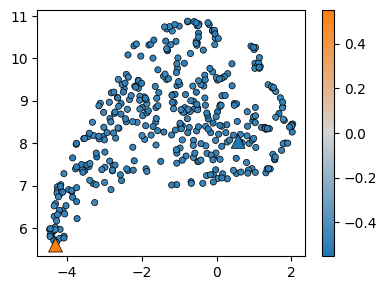

  pb_d10_e10_m0.5_lr001 Renin: plotted 405 cells


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bx2ur/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


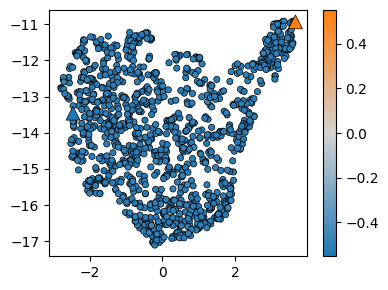

  pb_d10_e10_m0.5_lr001 Recruited: plotted 1177 cells


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/bx2ur/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


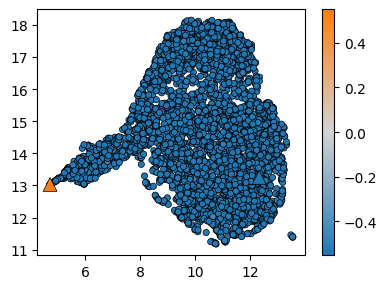

  pb_d10_e10_m0.5_lr001 Non_Renin: plotted 4609 cells


In [43]:
sc_metadata_path = "/home/bx2ur/code/renin_atac/metadata/renin_singlecell_data_with_label.csv"
sc_metadata = pd.read_csv(sc_metadata_path)

for cfg in configs:
    plot_sc_subgroup_tsne(cfg, sc_metadata)

## Per-config violin plots: subgroup means & per-cell-type breakdown

Two-panel figure per config. Left panel: one violin per subgroup
(`Renin` / `Recruited` / `Non_Renin`) showing the distribution of
reninness scores within each subgroup, colored by `SUBGROUP_COLORS`.
Right panel: one violin per cell type (from the metadata `Group` column),
with each cell type's violin colored by its dominant subgroup label.

In [44]:
from itertools import combinations
from scipy import stats

# Asterisk thresholds (Mann-Whitney U, two-sided). Same convention as
# GraphPad / common biology figures.
_SIG_LEVELS = [(1e-4, "****"), (1e-3, "***"), (1e-2, "**"), (5e-2, "*")]
_SIG_FOOTER = (
    "ns p>0.05  *  p≤0.05  **  p≤0.01  ***  p≤0.001  ****  p≤0.0001  "
    "(Mann–Whitney U, two-sided)"
)


def _sig_marker(p):
    for thr, mark in _SIG_LEVELS:
        if p <= thr:
            return mark
    return "ns"


def _annotate_pairs(ax, df, x_col, y_col, order, color="black"):
    """Add stacked significance bars + asterisks for every category pair.

    Mann-Whitney U on each pair. Bars are packed into the headroom between
    the top of the data and the existing y-axis ceiling — `ylim` is *not*
    extended, so a caller that set `set_ylim(-1, 1)` keeps that bound.
    """
    pos = {cat: i for i, cat in enumerate(order)}
    pairs = [(a, b) for a, b in combinations(order, 2)
             if (df[x_col] == a).any() and (df[x_col] == b).any()]
    if not pairs:
        return

    y_lo, y_hi = ax.get_ylim()
    span = y_hi - y_lo
    data_top = float(df.loc[df[x_col].isin(set(order)), y_col].astype(float).max())

    # Reserve the strip between (data_top + small gap) and (y_hi - small pad).
    base = data_top + span * 0.02
    ceiling = y_hi - span * 0.02
    available = ceiling - base
    if available <= 0:
        # Data already fills the axis — fall back to the top 25% of the range
        # and risk a tiny visual overlap with the violin tops.
        base = y_hi - span * 0.25
        available = span * 0.23
    step = available / max(len(pairs), 1)

    for k, (a, b) in enumerate(pairs):
        va = df.loc[df[x_col] == a, y_col].astype(float).to_numpy()
        vb = df.loc[df[x_col] == b, y_col].astype(float).to_numpy()
        if len(va) < 2 or len(vb) < 2:
            continue
        try:
            _, p = stats.mannwhitneyu(va, vb, alternative="two-sided")
        except ValueError:
            continue
        y = base + step * k
        x1, x2 = pos[a], pos[b]
        tick_h = step * 0.15
        ax.plot([x1, x1, x2, x2], [y, y + tick_h, y + tick_h, y],
                lw=1.0, c=color)
        ax.text((x1 + x2) / 2, y + tick_h, _sig_marker(p),
                ha="center", va="bottom", fontsize=9, color=color)

    # Restore caller's ylim in case any text artist nudged it.
    ax.set_ylim(y_lo, y_hi)


def plot_sc_violin(
    cfg,
    metadata_df,
    label_col="label",
    group_col="Group",
    name_col="file_name",
):
    """Two-panel violin plot for one config.

    Left  : reninness score distribution per subgroup (3 violins) +
            pairwise Mann–Whitney U significance bars.
    Right : reninness score distribution per cell type (`group_col`),
            each violin colored by that cell type's dominant subgroup.

    Panel widths are proportional to their category counts so that each
    individual violin gets the same horizontal slot on screen.

    Output: <bar_plts[cfg]>/<cfg>_violin.svg
    """
    os.makedirs(bar_plts[cfg], exist_ok=True)

    score = pd.read_csv(score_paths[cfg])
    if "filename" in score.columns and "name" not in score.columns:
        score = score.rename(columns={"filename": "name"})

    md_key = name_col if name_col in metadata_df.columns else "filename"
    merged = score.merge(
        metadata_df[[md_key, label_col, group_col]].rename(columns={md_key: "name"}),
        on="name", how="inner",  # drops label rows / unmatched samples
    )

    # ---- per-cell-type ordering / palette -----------------------------------
    group_to_label = (
        merged.groupby(group_col)[label_col]
        .agg(lambda s: s.value_counts().idxmax())
    )
    # Order cell types by median reninness score, high (left) → low (right):
    # Renin-leaning on the left, Non_Renin-leaning on the right. Color each
    # violin by its dominant subgroup so subgroup membership is still
    # readable after re-ordering.
    group_order = list(
        merged.groupby(group_col)["score"].median()
        .sort_values(ascending=False).index
    )
    group_palette = {
        g: SUBGROUP_COLORS.get(group_to_label[g], "lightgray")
        for g in group_order
    }

    # ---- figure: widths proportional to category counts so the on-screen
    #       width of each violin slot is the same in both panels ---------
    n_left = len(SUBGROUPS)
    n_right = len(group_order)
    per_slot = 0.45  # inches per violin slot — tighter = groups appear closer
    fig_w = max(7, per_slot * (n_left + n_right) + 2)
    fig, axes = plt.subplots(
        1, 2, figsize=(fig_w, 5),
        gridspec_kw={"width_ratios": [n_left, n_right]},
    )

    # ---- left: per-subgroup violins + pairwise stat bars ----------------
    sns.violinplot(
        data=merged, x=label_col, y="score",
        order=SUBGROUPS, palette=SUBGROUP_COLORS,
        ax=axes[0], inner=None, cut=0,
        width=0.6, linewidth=0.6,
    )
    # Overlay a narrow boxplot for median/IQR/whiskers; showfliers=True
    # draws outlier points (beyond 1.5x IQR) as dots — no full strip.
    sns.boxplot(
        data=merged, x=label_col, y="score",
        order=SUBGROUPS,
        ax=axes[0], width=0.12, linewidth=0.6,
        showfliers=True, fliersize=1.5,
        boxprops=dict(facecolor="white", edgecolor="black"),
        whiskerprops=dict(color="black", linewidth=0.6),
        capprops=dict(color="black", linewidth=0.6),
        medianprops=dict(color="black", linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="black",
                        markeredgecolor="none", alpha=0.5),
    )
    axes[0].set_ylim(-1, 1)
    axes[0].set_title(f"{cfg}: reninness score by subgroup")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("reninness score")
    _annotate_pairs(axes[0], merged, label_col, "score", SUBGROUPS)

    # ---- right: per-cell-type violins, colored by dominant subgroup -----
    sns.violinplot(
        data=merged, x=group_col, y="score",
        order=group_order, palette=group_palette,
        ax=axes[1], inner=None, cut=0,
        width=0.6, linewidth=0.6,
    )
    sns.boxplot(
        data=merged, x=group_col, y="score",
        order=group_order,
        ax=axes[1], width=0.12, linewidth=0.6,
        showfliers=True, fliersize=1.3,
        boxprops=dict(facecolor="white", edgecolor="black"),
        whiskerprops=dict(color="black", linewidth=0.6),
        capprops=dict(color="black", linewidth=0.6),
        medianprops=dict(color="black", linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="black",
                        markeredgecolor="none", alpha=0.5),
    )
    axes[1].set_ylim(-1, 1)
    axes[1].set_title(f"{cfg}: reninness score by cell type (color = subgroup)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    for tick in axes[1].get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha("right")

    # Asterisk legend at the bottom of the figure.
    fig.text(0.5, -0.02, _SIG_FOOTER, ha="center", va="top", fontsize=9,
             color="dimgray")

    plt.tight_layout()
    out = os.path.join(bar_plts[cfg], f"{cfg}_violin.svg")
    plt.savefig(out, format="svg", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  saved {out}")

/tmp/ipykernel_364985/3863571543.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_364985/3863571543.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


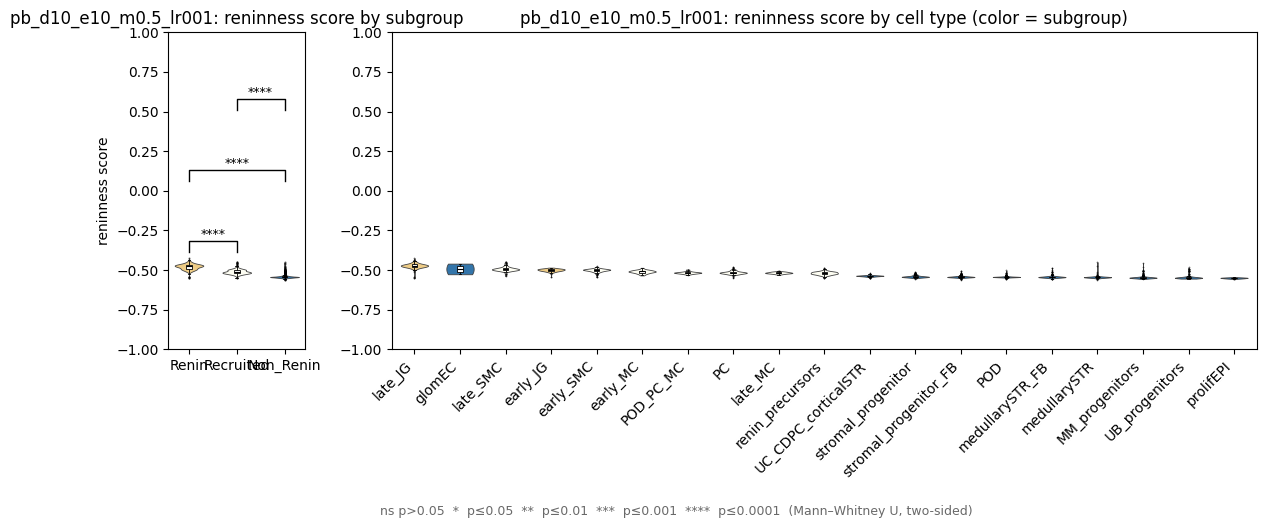

  saved /project/shefflab/brickyard/results_pipeline/gomez_atac/results_pipeline/pseudobulk_reninness_score_output/universe_cc_20260414_195834/pb_d10_e10_m0.5_lr001/sc/plot/bar/pb_d10_e10_m0.5_lr001_violin.svg


In [48]:
for cfg in configs:
    plot_sc_violin(cfg, sc_metadata)